In [131]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dropout
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense

In [132]:
(x_train,y_train),(x_test,y_test)= mnist.load_data()

In [133]:
print('Training data: ',x_train.shape,y_train.shape)
print('Testing data: ',x_test.shape,y_test.shape)

print(y_test[:10])

Training data:  (60000, 28, 28) (60000,)
Testing data:  (10000, 28, 28) (10000,)
[7 2 1 0 4 1 4 9 5 9]


In [134]:
# 60,000 training examples, 10000 testing examples. And 28*28 = 784 col's

# 

In [135]:
total_classes = np.unique(y_train)
print(total_classes)

number_of_total_classes =  len(total_classes)
print('Total number of output classes are: ',number_of_total_classes)

[0 1 2 3 4 5 6 7 8 9]
Total number of output classes are:  10


In [136]:
x_test[:5].shape

(5, 28, 28)

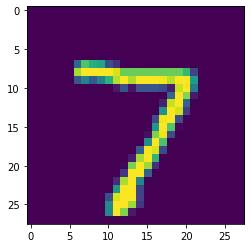

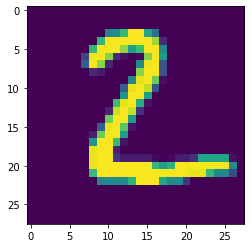

In [142]:
for i in (x_test[:2]):
    plt.imshow(i)
    plt.show()

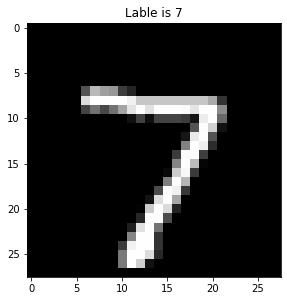

In [55]:
plt.figure(figsize=[10,15])
plt.subplot(122)

plt.imshow(x_test[0],cmap='gray');
plt.title(f"Lable is {y_test[0]}");



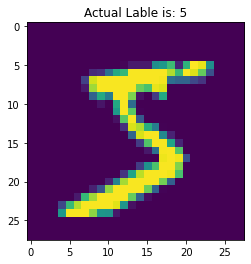

In [56]:
plt.imshow(x_train[0]);
plt.title(f"Actual Lable is: {y_train[0]}",);

In [67]:
new_dimensional_data = np.prod(x_train.shape[1:])

x_train = x_train.reshape(x_train.shape[0], new_dimensional_data)
x_test  = x_test.reshape(x_test.shape[0], new_dimensional_data)

print(x_train.shape)
print(x_test.shape)

#pd.DataFrame(x_test)

(60000, 784)
(10000, 784)


In [61]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [62]:
x_train /= 255
x_test /= 255

In [124]:
y_test[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

In [90]:
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

In [126]:
y_test_one_hot[:10]

array([[0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]], dtype=float32)

In [91]:
x_test_one_hot.shape

(10000, 10)

In [108]:
print("Original Lable is 6: ",y_train[10])

print("After Conversion to categorical ( one_hot ): ",y_train_one_hot[10])

Original Lable is 6:  3
After Conversion to categorical ( one_hot ):  [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


In [93]:
# weights in first layer [512,784], in second layer is [512,512]

In [94]:
print(new_dimensional_data)
print(number_of_total_classes)

784
10


In [95]:
model = Sequential()

model.add(Dense(512, activation='relu',input_shape=(new_dimensional_data,)))
model.add(Dense(512,activation='relu'))
model.add(Dense(number_of_total_classes,activation='softmax'))

In [101]:
model.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [102]:
history = model.fit(x_train,y_train_one_hot,batch_size=256,epochs=10,verbose=1,validation_data=(x_test,y_test_one_hot))

Epoch 1/10
235/235 [==============================] - 7s 26ms/step - loss: 0.1633 - accuracy: 0.9532 - val_loss: 0.1609 - val_accuracy: 0.9521
Epoch 2/10
235/235 [==============================] - 6s 24ms/step - loss: 0.1575 - accuracy: 0.9550 - val_loss: 0.1567 - val_accuracy: 0.9536
Epoch 3/10
235/235 [==============================] - 5s 23ms/step - loss: 0.1537 - accuracy: 0.9557 - val_loss: 0.1542 - val_accuracy: 0.9540
Epoch 4/10
235/235 [==============================] - 5s 23ms/step - loss: 0.1506 - accuracy: 0.9568 - val_loss: 0.1511 - val_accuracy: 0.9549
Epoch 5/10
235/235 [==============================] - 5s 23ms/step - loss: 0.1477 - accuracy: 0.9577 - val_loss: 0.1491 - val_accuracy: 0.9553
Epoch 6/10
235/235 [==============================] - 5s 23ms/step - loss: 0.1452 - accuracy: 0.9582 - val_loss: 0.1475 - val_accuracy: 0.9550
Epoch 7/10
235/235 [==============================] - 5s 23ms/step - loss: 0.1428 - accuracy: 0.9592 - val_loss: 0.1452 - val_accuracy: 0.9561

In [109]:
y_pred = model.predict(x_test)
y_pred

313/313 [==============================] - 2s 6ms/step


array([[7.8283911e-06, 5.3359105e-07, 5.1782053e-04, ..., 9.9787915e-01,
        3.9962315e-06, 1.1856799e-04],
       [1.6533335e-05, 2.7271459e-04, 9.9160391e-01, ..., 4.9363440e-08,
        4.3352510e-04, 3.4465444e-08],
       [3.8158705e-05, 9.9165404e-01, 1.8380055e-03, ..., 2.9846609e-03,
        1.1966223e-03, 1.8933314e-04],
       ...,
       [3.4084883e-07, 9.7124584e-08, 1.5716547e-06, ..., 1.6131275e-04,
        7.0537784e-04, 4.1536246e-03],
       [3.8735025e-06, 9.0491412e-06, 1.5605519e-06, ..., 7.7780633e-08,
        1.3196298e-03, 3.9322970e-07],
       [5.7779885e-06, 4.1179373e-08, 5.8742393e-05, ..., 2.6381941e-09,
        1.3496570e-07, 1.3740503e-08]], dtype=float32)

In [110]:
y_pred_lable = np.argmax(y_pred,axis=1)

In [111]:
y_pred_lable

array([7, 2, 1, ..., 4, 5, 6], dtype=int64)

In [112]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [117]:
from sklearn.metrics import confusion_matrix

In [118]:
confusion_matrix(y_test,y_pred_lable)

array([[ 965,    0,    2,    1,    0,    5,    4,    2,    1,    0],
       [   0, 1121,    3,    1,    0,    1,    2,    1,    6,    0],
       [   7,    2,  975,   10,    4,    1,    6,    8,   17,    2],
       [   0,    2,   11,  962,    0,    9,    0,   10,   12,    4],
       [   1,    0,    4,    0,  945,    0,   10,    3,    2,   17],
       [   5,    2,    0,   17,    2,  840,    9,    0,   11,    6],
       [  10,    3,    1,    0,   10,    9,  919,    1,    5,    0],
       [   0,    9,   15,    4,    2,    1,    0,  983,    2,   12],
       [   4,    1,    3,   14,    5,    7,    8,    7,  920,    5],
       [   7,    6,    2,   11,   21,    3,    1,    8,    6,  944]],
      dtype=int64)

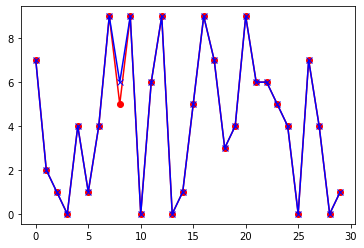

In [123]:
plt.plot(range(len(y_test))[:30],y_test[:30],color='r',label='Ground Truth',linestyle='-',marker='o')

plt.plot(range(len(y_test))[:30],y_pred_lable[:30],color='b',label='Predicted',linestyle='-',marker='x');

In [4]:
!pip install torch torchvision torchaudio

   -------------------------------------- 198.1/198.1 MB 750.9 kB/s eta 0:00:00
   ---------------------------------------- 1.3/1.3 MB 345.7 kB/s eta 0:00:00
   ---------------------------------------- 2.4/2.4 MB 538.8 kB/s eta 0:00:00


ERROR: Exception:
Traceback (most recent call last):
  File "c:\downloaded software\lib\site-packages\pip\_internal\cli\base_command.py", line 105, in _run_wrapper
    status = _inner_run()
  File "c:\downloaded software\lib\site-packages\pip\_internal\cli\base_command.py", line 96, in _inner_run
    return self.run(options, args)
  File "c:\downloaded software\lib\site-packages\pip\_internal\cli\req_command.py", line 67, in wrapper
    return func(self, options, args)
  File "c:\downloaded software\lib\site-packages\pip\_internal\commands\install.py", line 483, in run
    installed_versions[distribution.canonical_name] = distribution.version
  File "c:\downloaded software\lib\site-packages\pip\_internal\metadata\pkg_resources.py", line 192, in version
    return parse_version(self._dist.version)
  File "c:\downloaded software\lib\site-packages\pip\_vendor\packaging\version.py", line 56, in parse
    return Version(version)
  File "c:\downloaded software\lib\site-packages\pip\_vendor\p

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./ANN', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./ANN', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|████████████████████████████████████████████████████████████████████| 9912422/9912422 [00:11<00:00, 841980.60it/s]


Extracting ./ANN\MNIST\raw\train-images-idx3-ubyte.gz to ./ANN\MNIST\raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|█████████████████████████████████████████████████████████████████████████| 28881/28881 [00:00<00:00, 52155.77it/s]


Extracting ./ANN\MNIST\raw\train-labels-idx1-ubyte.gz to ./ANN\MNIST\raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|████████████████████████████████████████████████████████████████████| 1648877/1648877 [00:02<00:00, 779846.38it/s]


Extracting ./ANN\MNIST\raw\t10k-images-idx3-ubyte.gz to ./ANN\MNIST\raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████████████████████████████████████████████████████████████████████████████████| 4542/4542 [00:00<?, ?it/s]

Extracting ./ANN\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./ANN\MNIST\raw



In [10]:
test_loader